In [5]:
import pandas as pd
import matplotlib.pyplot as plt

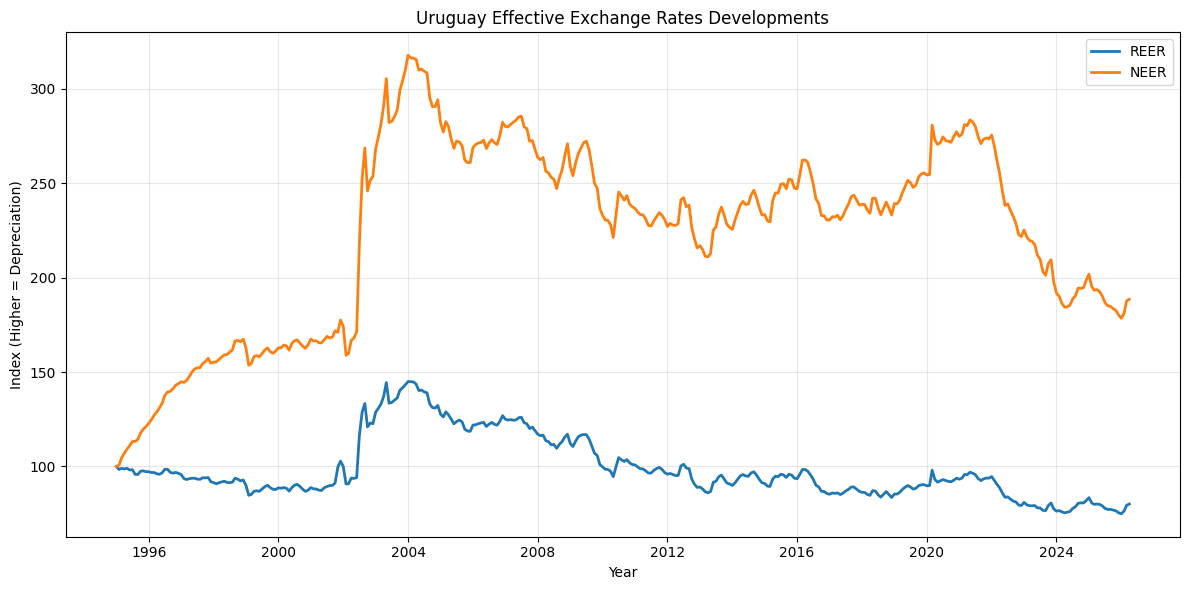

In [4]:
df = pd.read_csv("neer_reer_uruguay.csv")

# Convert date
df["TIME_PERIOD"] = pd.to_datetime(
    df["TIME_PERIOD"].str.replace("-M", "-"),
    format="%Y-%m"
)

# Convert value
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"])

# =========================
# SPLIT NEER & REER
# =========================

neer = df[df["INDICATOR"].str.contains("NEER")][
    ["TIME_PERIOD", "OBS_VALUE"]
].rename(columns={"OBS_VALUE": "NEER_IMF"})

reer = df[df["INDICATOR"].str.contains("REER")][
    ["TIME_PERIOD", "OBS_VALUE"]
].rename(columns={"OBS_VALUE": "REER_IMF"})

# =========================
# MERGE
# =========================

plot_df = pd.merge(
    neer,
    reer,
    on="TIME_PERIOD",
    how="inner"
)

# =========================
# LAST 30 YEARS
# =========================

plot_df = plot_df[
    plot_df["TIME_PERIOD"] >= "1995-01-01"
].copy()

# =========================
# CONVERT TO COURSE CONVENTION
# Higher index = depreciation
# =========================

base_neer = plot_df["NEER_IMF"].iloc[0]
base_reer = plot_df["REER_IMF"].iloc[0]

plot_df["NEER"] = (
    base_neer / plot_df["NEER_IMF"]
) * 100

plot_df["REER"] = (
    base_reer / plot_df["REER_IMF"]
) * 100

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

plt.plot(
    plot_df["TIME_PERIOD"],
    plot_df["REER"],
    label="REER",
    linewidth=2
)

plt.plot(
    plot_df["TIME_PERIOD"],
    plot_df["NEER"],
    label="NEER",
    linewidth=2
)

plt.title("Uruguay Effective Exchange Rates Developments")
plt.xlabel("Year")
plt.ylabel("Index (Higher = Depreciation)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
